In [1]:
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.tree import DecisionTreeClassifier, plot_tree

## Get the Data

In [2]:
#https://www.kaggle.com/uciml/iris

url_='https://drive.google.com/uc?id=10vsX925g8ff4QdgQpnsguo4DHUHOPgAL'
df = pd.read_csv(url_)

In [3]:
df.shape

(150, 6)

In [4]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df.columns

Index(['Id', 'SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm',
       'Species'],
      dtype='object')

In [6]:
X = df.drop(['Id', 'Species'], axis = 1)
y = df['Species']

In [7]:
type(X) # DataFrame

pandas.core.frame.DataFrame

In [8]:
type(y) # Series

pandas.core.series.Series

In [9]:
X

,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


In [10]:
y

,Species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa
...,...
145,Iris-virginica
146,Iris-virginica
147,Iris-virginica
148,Iris-virginica


In [11]:
set(y) ## labels

{'Iris-setosa', 'Iris-versicolor', 'Iris-virginica'}

In [12]:
X.shape

(150, 4)

In [13]:
y.shape

(150,)

## Split data to Train and Test Sets

In [14]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20) # 20%

In [15]:
(X_train.shape, y_train.shape)

((120, 4), (120,))

In [16]:
(X_test.shape, y_test.shape)

((30, 4), (30,))

### Decision Tree - create instance

In [17]:
# https://scikit-learn.org/stable/modules/generated/sklearn.tree.DecisionTreeClassifier.html
model = DecisionTreeClassifier(criterion='gini')

### Decision Tree - train model

In [18]:
model.fit(X_train, y_train)

DecisionTreeClassifier()

### Decision Tree - make a prediction

In [19]:
y_pred = model.predict(X_test)
y_pred_s = pd.Series(y_pred)

In [20]:
type(y_pred)

numpy.ndarray

In [21]:
y_pred_s

,0
0,Iris-virginica
1,Iris-virginica
2,Iris-virginica
3,Iris-versicolor
4,Iris-versicolor
5,Iris-versicolor
6,Iris-setosa
7,Iris-virginica
8,Iris-versicolor
9,Iris-versicolor


In [22]:
type(y_test)

pandas.core.series.Series

In [23]:
# combine to view
s3 = pd.Series(list(zip(y_pred_s, y_test)))
s3

,0
0,"(Iris-virginica, Iris-virginica)"
1,"(Iris-virginica, Iris-virginica)"
2,"(Iris-virginica, Iris-virginica)"
3,"(Iris-versicolor, Iris-versicolor)"
4,"(Iris-versicolor, Iris-versicolor)"
5,"(Iris-versicolor, Iris-versicolor)"
6,"(Iris-setosa, Iris-setosa)"
7,"(Iris-virginica, Iris-virginica)"
8,"(Iris-versicolor, Iris-versicolor)"
9,"(Iris-versicolor, Iris-virginica)"


## Model Evaluation

In [24]:
from sklearn.metrics import classification_report, confusion_matrix

In [25]:
print(classification_report(y_test, y_pred))

                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00         7
Iris-versicolor       0.82      1.00      0.90         9
 Iris-virginica       1.00      0.86      0.92        14

       accuracy                           0.93        30
      macro avg       0.94      0.95      0.94        30
   weighted avg       0.95      0.93      0.93        30



In [26]:
print(confusion_matrix(y_test, y_pred))

[[ 7  0  0]
 [ 0  9  0]
 [ 0  2 12]]


## Visualization

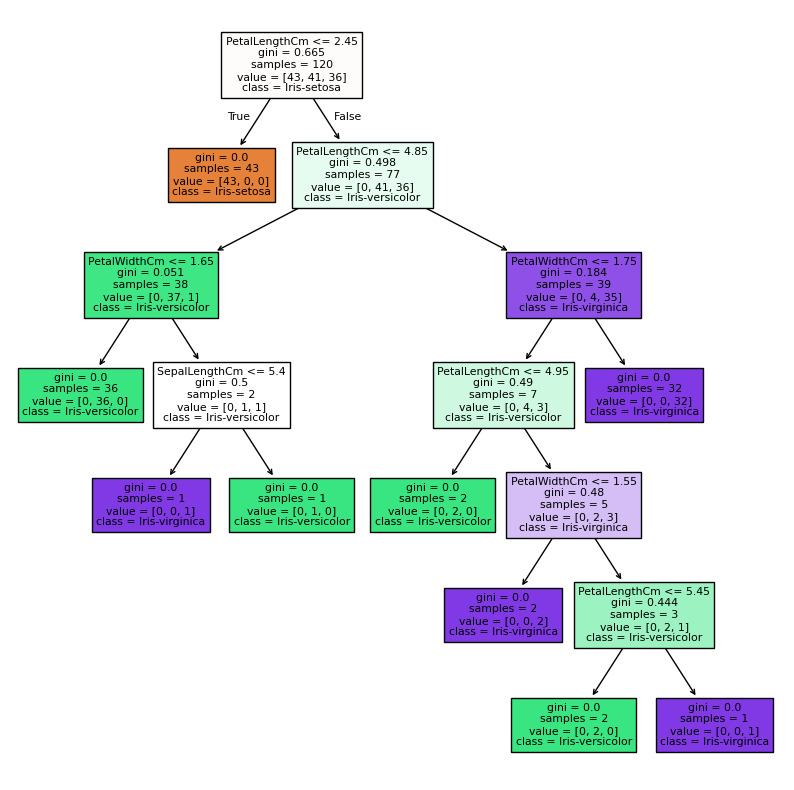

In [27]:
plt.figure(figsize = (10, 10))
plot_tree(model, feature_names = ['SepalLengthCm', 'SepalWidthCm', 'PetalLengthCm', 'PetalWidthCm'],
          class_names = ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], filled = True)
plt.show()